   Order_ID Customer_Name     Category    Sales  Quantity  Order_Date
0      1001         Rahul  Electronics  25000.0       2.0  2026-01-10
1      1002         Priul     Clothing   3500.0       1.0  2026-01-11
2      1003          Amit    Furniture  12000.0       3.0  2026-01-12
3      1004         Sneha  Electronics  18000.0       1.0  2026-01-13
4      1005         Karan     Clothing      NaN       2.0  2026-01-14
Order_ID         0
Customer_Name    0
Category         0
Sales            1
Quantity         1
Order_Date       1
dtype: int64
MAE : 11492.91237113408
MSE : 158372476.6513459
RMSE : 12584.612693736184
R2 Score : -7.76802638900185


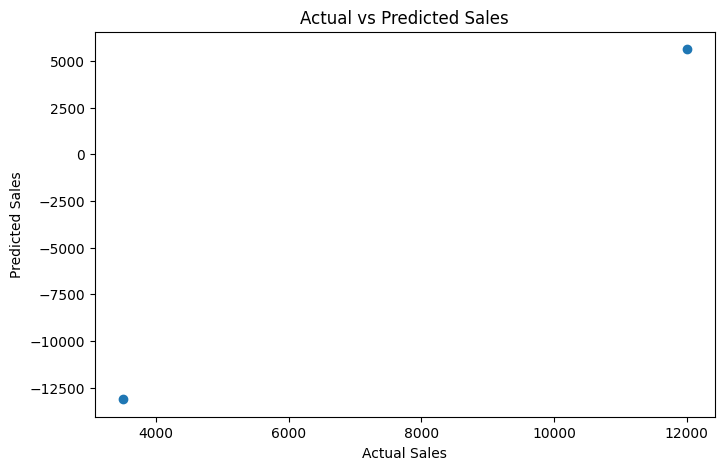

Predicted Sales: 61895.618556700996


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_excel('/content/raw_data.xlsx')

# Display first 5 rows
print(df.head())

# Check missing values
print(df.isnull().sum())

# Handle missing values: Impute numerical columns with median and drop rows with missing 'Order_Date'
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df = df.dropna(subset=['Order_Date']) # Drop rows where Order_Date is NaN

# Convert Date column to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Feature Engineering
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day'] = df['Order_Date'].dt.day

# Features and Target
X = df[['Year', 'Month', 'Day']]
y = df['Sales']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

# Actual vs Predicted Plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

# Future Prediction Example
future_data = pd.DataFrame({
    'Year': [2027],
    'Month': [8],
    'Day': [15]
})

future_prediction = model.predict(future_data)
print("Predicted Sales:", future_prediction[0])